In [2]:
from pathlib import Path

for f in Path("../data/raw/cornie").rglob("*"):
    print(f.name)

cornie.cpg
cornie.dbf
cornie.prj
cornie.shp
cornie.shx


In [3]:
import geopandas as gpd
import pandas as pd

In [4]:
cornie = gpd.read_file(
    "../data/raw/cornie/cornie.shp"
)

cornie.head()

,OBJECTID,Code_18,Remark,Area_Ha,ID,Shape_Leng,Shape_Area,geometry
0,405657,111,None,78.111766,EU_405657,4293.812250,781117.65625,"POLYGON ((-5.08634 50.41792, -5.08633 50.41773..."
1,405876,112,None,36.377628,EU_405876,4538.893729,363776.28045,"POLYGON ((-5.19775 49.97136, -5.19777 49.97135..."
2,405877,112,None,50.763579,EU_405877,5049.852632,507635.79455,"POLYGON ((-5.17758 49.98675, -5.17788 49.98673..."
3,405878,112,None,29.103907,EU_405878,4122.320986,291039.06915,"POLYGON ((-5.09498 50.02141, -5.09513 50.02136..."
4,405879,112,None,25.287599,EU_405879,2742.232369,252875.98560,"POLYGON ((-5.08736 50.04886, -5.08901 50.04827..."


In [5]:
print(cornie.shape)

cornie.columns.tolist()

(74636, 8)


['OBJECTID',
 'Code_18',
 'Remark',
 'Area_Ha',
 'ID',
 'Shape_Leng',
 'Shape_Area',
 'geometry']

In [6]:
cornie.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
cornie.geom_type.value_counts()

Polygon         73644
MultiPolygon      992
Name: count, dtype: int64

In [8]:
cornie["Code_18"].value_counts().sort_index()

Code_18
111      295
112     6208
121     2709
122      228
123      125
124      181
131      869
132       87
133      262
141      967
142     3811
211     7161
222       98
231    13399
242      157
243     1084
244        1
311     7023
312     5702
313     3309
321     5233
322     5036
324     4204
331      113
332      162
333     1077
334        3
411      156
412     2273
421      267
423      653
511       49
512     1605
521        7
522      115
523        7
Name: count, dtype: int64

In [9]:

wind_gdf = gpd.read_parquet(
    "../data/interim/repd_processed/wind_farm_crs.parquet"
)

In [10]:
wind_gdf.head()

,Site Name,Technology Type,Installed Capacity (MWelec),Turbine Capacity (MW),No. of Turbines,Height of Turbines (m),Development Status,Region,Country,X-coordinate,Y-coordinate,geometry
0,Hywind Scotland Pilot Park (Hywind 2) Demonstr...,Wind Offshore,30,6,5,None,Operational,Offshore,Scotland,433500,846500,POINT (-1.44258 57.50746)
1,Beatrice Demonstrator,Wind Offshore,10,5,2,None,Operational,Offshore,Scotland,347955,929690,POINT (-2.88843 58.25281)
2,Burbo Bank,Wind Offshore,90,3.6,25,None,Operational,Offshore,England,321476,399706,POINT (-3.18492 53.48818)
3,Gunfleet Sands - (Demo) Extension,Wind Offshore,12,6,2,None,Operational,Offshore,England,620650,205297,POINT (1.19191 51.70301)
4,Gunfleet Sands II,Wind Offshore,64.8,3.6,18,None,Operational,Offshore,England,624262,208150,POINT (1.24592 51.72719)


In [26]:
type(wind_gdf)

geopandas.geodataframe.GeoDataFrame

In [27]:
wind_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [11]:
wind_cornie = gpd.sjoin(
    wind_gdf,
    cornie[["Code_18", "geometry"]],
    how="left",
    predicate="within"
)

In [12]:
wind_cornie.head()

,Site Name,Technology Type,Installed Capacity (MWelec),Turbine Capacity (MW),No. of Turbines,Height of Turbines (m),Development Status,Region,Country,X-coordinate,Y-coordinate,geometry,index_right,Code_18
0,Hywind Scotland Pilot Park (Hywind 2) Demonstr...,Wind Offshore,30,6,5,None,Operational,Offshore,Scotland,433500,846500,POINT (-1.44258 57.50746),NaN,NaN
1,Beatrice Demonstrator,Wind Offshore,10,5,2,None,Operational,Offshore,Scotland,347955,929690,POINT (-2.88843 58.25281),NaN,NaN
2,Burbo Bank,Wind Offshore,90,3.6,25,None,Operational,Offshore,England,321476,399706,POINT (-3.18492 53.48818),NaN,NaN
3,Gunfleet Sands - (Demo) Extension,Wind Offshore,12,6,2,None,Operational,Offshore,England,620650,205297,POINT (1.19191 51.70301),NaN,NaN
4,Gunfleet Sands II,Wind Offshore,64.8,3.6,18,None,Operational,Offshore,England,624262,208150,POINT (1.24592 51.72719),NaN,NaN


In [13]:
wind_cornie["Code_18"].isna().sum()

np.int64(49)

In [31]:
wind_cornie["Code_18"].value_counts().sort_index()

Code_18
112     21
121    130
122      2
123      6
124      1
131      6
133      3
142      7
211    187
231    169
242      2
243      4
311      2
312     31
313      3
321     56
322     54
324     29
333      1
412     58
421      2
423      1
512      1
Name: count, dtype: int64

In [32]:
wind_cornie[
    wind_cornie["Code_18"].isna()
][
    [
        "Site Name",
        "Technology Type",
        "Country"
    ]
]

,Site Name,Technology Type,Country
0,Hywind Scotland Pilot Park (Hywind 2) Demonstr...,Wind Offshore,Scotland
1,Beatrice Demonstrator,Wind Offshore,Scotland
2,Burbo Bank,Wind Offshore,England
3,Gunfleet Sands - (Demo) Extension,Wind Offshore,England
4,Gunfleet Sands II,Wind Offshore,England
5,Gunfleet Sands Offshore Wind Scheme,Wind Offshore,England
6,Inner Dowsing,Wind Offshore,England
7,Kentish Flats,Wind Offshore,England
8,Lynn,Wind Offshore,England
9,North Hoyle,Wind Offshore,Wales


In [33]:
wind_cornie.groupby(
    "Technology Type"
)["Code_18"].apply(
    lambda x: x.isna().sum()
)

Technology Type
Wind Offshore    47
Wind Onshore      2
Name: Code_18, dtype: int64

In [34]:
print("Total farms:", len(wind_cornie))

print("Matched Farms:",
      wind_cornie["Code_18"].notna().sum())


print("Unmatched Farms:",
      wind_cornie["Code_18"].isna().sum())

Total farms: 825
Matched Farms: 776
Unmatched Farms: 49


In [35]:
wind_cornie[
    (wind_cornie["Code_18"].isna()) &
    (wind_cornie["Technology Type"] == "Wind Onshore")
][
    [
        "Site Name",
        "X-coordinate",
        "Y-coordinate",
        "Region",
        "Country"
    ]
]

,Site Name,X-coordinate,Y-coordinate,Region,Country
321,Blyth Harbour Wind Farm,432290,581345,North East,England
750,Blyth Harbour Wind Farm (re-power),432029,581759,North East,England


<Axes: >

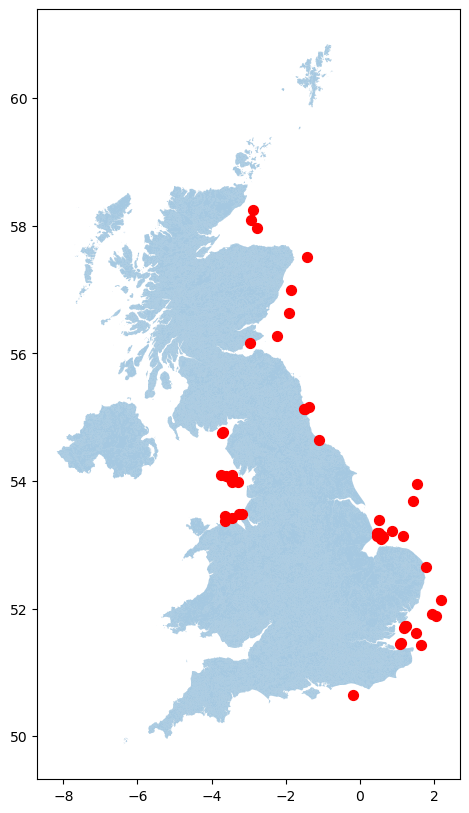

In [14]:
unmatched = wind_cornie[
    wind_cornie["Code_18"].isna()
]

ax = cornie.plot(
    figsize= (10,10),
    alpha=0.4
)

unmatched.plot(
    ax=ax,
    color="red",
    markersize=50
)

In [15]:
wind_cornie["landcover_status"] = "Matched"

wind_cornie.loc[
    wind_cornie["Technology Type"] == "Wind Offhosre",
    "landcover_status"
] = "Offshore"

wind_cornie.loc[
    wind_cornie["Code_18"].isna() &
    (wind_cornie["Technology Type"] == "Wind Onshore"),
    "landcover_status"
] = "Unclassified"

In [17]:
wind_cornie.tail()

,Site Name,Technology Type,Installed Capacity (MWelec),Turbine Capacity (MW),No. of Turbines,Height of Turbines (m),Development Status,Region,Country,X-coordinate,Y-coordinate,geometry,index_right,Code_18,landcover_status
820,Land near Ventonteague,Wind Onshore,2.3,None,1,99,Operational,South West,England,182586,51229,POINT (-5.05556 50.3208),231.0,211,Matched
821,Limekiln Wind Farm (Extension),Wind Onshore,21,None,5,149.9,Operational,Scotland,Scotland,300298,961309,POINT (-3.71381 58.52844),64928.0,312,Matched
822,Lower Rumster wind turbine,Wind Onshore,0.2,None,3,35,Operational,Scotland,Scotland,321714,936327,POINT (-3.33765 58.30852),69070.0,322,Matched
823,Mounteneys and Cherry Rock Wind Turbines,Wind Onshore,1,0.5,2,77,Operational,South West,England,373296,189365,POINT (-2.38696 51.60249),29475.0,231,Matched
824,Watsonhead Wind Farm,Wind Onshore,8.4,4.2,2,149.38,Operational,Scotland,Scotland,284443,655006,POINT (-3.84375 55.77453),27565.0,211,Matched


In [18]:
wind_cornie.to_parquet(
    "../data/interim/cornie_processed/wind_cornie.parquet",
    index=False
)

In [20]:
wind_cornie.to_csv(
    "../data/interim/cornie_processed/wind_cornie.csv",
    index=False
)

In [21]:
wind_cornie.to_file(
    "../data/interim/cornie_processed/wind_cornie.shp"
)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_23008\3079432921.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  wind_cornie.to_file(
c:\Users\LOQ\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Technology Type' to 'Technology'
  ogr_write(
c:\Users\LOQ\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Installed Capacity (MWelec)' to 'Installed'
  ogr_write(
c:\Users\LOQ\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Turbine Capacity (MW)' to 'Turbine Ca'
  ogr_write(
c:\Users\LOQ\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'No. of Turbines' to 'No. of Tur'
  ogr_write(
c:\Users\LOQ\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Height of Turbines (m)' to 'Height of'
  ogr_write(
c:\U